**Simple deep model**

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**keras callbacks**

**Step decay**
keeps the learning rate constant for some epochs
Then suddenly reduce it by a fixed factor
repeat this process in steps

In [ ]:
import math
from tensorflow.keras import callbacks

def step_decay(epoch):
  initial_lrate = 0.01
  drop = 0.5
  epochs_drop = 10.0
    #formula -- lrate = initial_lrate * (drop ^ math.floor((1 + epoch) / epochs_drop))
  lrate = initial_lrate  * math.pow(drop, math.floor((1 + epoch)/ epochs_drop))
  return lrate

lr_schedular = callbacks.LearningRateScheduler(step_decay, verbose=1)

history = model.fit(
    x_train, y_train,
    epoch = 50,
    validation_data=(x_val, y_val),
    callbacks=[lr_schedular]
)

#1. Epoch starts
#2. Keras calls step_decay(epoch)
#3. Learning rate is updated
#4. Model trains for one epoch
#5. Accuracy & loss printed
#6. Repeat

NameError: name 'x_train' is not defined

**Exponential decay**
Starts with high learning rate
Reduces it gradually and smoothly
The reduction happens continuously, not suddenly

NOTE -->

1.   Step decay = Stairs
2.   Exponential decay = smooth slope



In [ ]:
from tensorflow.keras import optimizers

#internal formula for exponentialDecay --> learning_rate = initial_lr × decay_rate ^ (step / decay_steps)
lr_schedule = optimizers.schedules.ExponentialDecay(
    intitial_lrate = 0.01,
    decay_steps = 10000, #no. of steps before decreasing
    decay_rate = 0.96, #base of the exponential
    staircase = False #set true if you want step like effect
)
optimizer = optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer= optimizer, loss='sparse_categorical_crossentropy')

TypeError: ExponentialDecay.__init__() got an unexpected keyword argument 'intitial_lrate'

**ReduceLRonPlateau**
If the model stops improving, reduce the learning rate

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


# Learning Rate Decay: Reduces LR by factor of 0.2 if val_loss plateaus for 3 epochs
lr_decay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)

# 3. Train the Model
# Pass the callbacks list to the fit function
history = model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, lr_decay]
)

Epoch 1/50


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "dense" is incompatible with the layer: expected axis -1 of input shape to have value 784, but received input with shape (None, 20)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(None, 20), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

**Early Stopping**

In [ ]:
# Early Stopping: Stops training if validation loss doesn't improve for 5 epochs
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

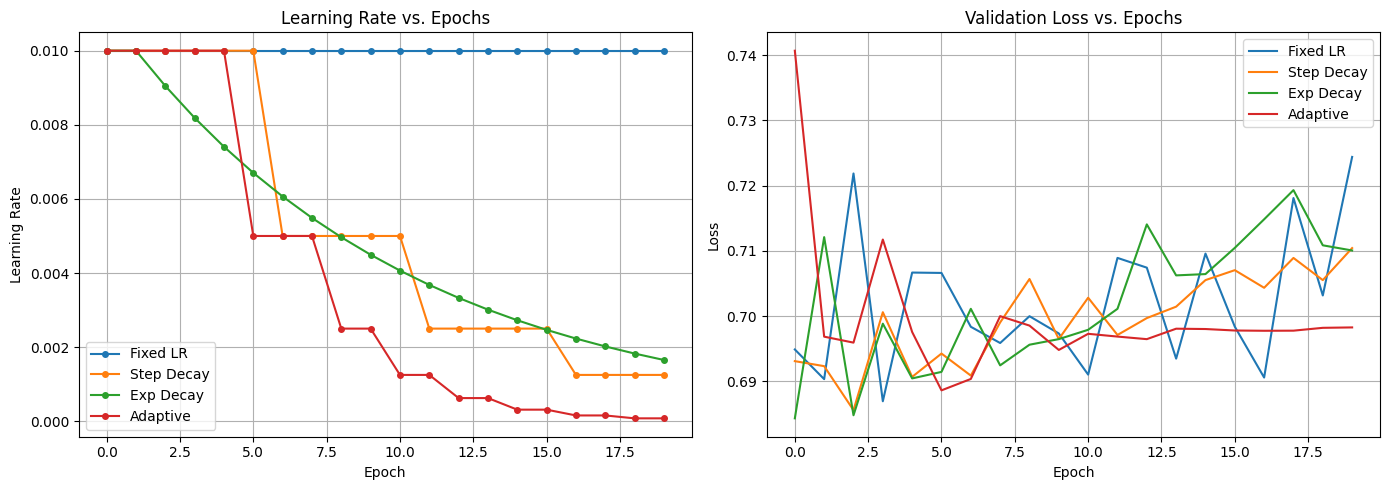

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt

# 1. Setup Synthetic Data (to ensure the code runs without external datasets)
x_train = np.random.random((1000, 20))
y_train = np.random.randint(0, 2, (1000,))
x_val = np.random.random((200, 20))
y_val = np.random.randint(0, 2, (200,))

# 2. Scheduling Functions
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 5
    return float(initial_lr * (drop ** (epoch // epochs_drop)))

def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    return float(initial_lr * np.exp(-k * epoch))

# 3. Training Function
def train_model(name, callback_list=None, initial_lr=0.01):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(20,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=initial_lr),
                  loss='binary_crossentropy')

    # Custom callback to capture LR at each epoch
    class LRHistory(callbacks.Callback):
        def on_epoch_begin(self, epoch, logs=None):
            if not hasattr(self, 'lrs'): self.lrs = []
            self.lrs.append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))

    lr_tracker = LRHistory()
    cbs = [lr_tracker] + (callback_list if callback_list else [])

    history = model.fit(x_train, y_train, epochs=20, validation_data=(x_val, y_val),
                        callbacks=cbs, verbose=0)
    return history.history['val_loss'], lr_tracker.lrs

# 4. Run Comparisons
results = {
    'Fixed LR': train_model('Fixed'),
    'Step Decay': train_model('Step', [callbacks.LearningRateScheduler(step_decay)]),
    'Exp Decay': train_model('Exp', [callbacks.LearningRateScheduler(exp_decay)]),
    'Adaptive': train_model('Adaptive', [callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)])
}

# 5. Visualization
plt.figure(figsize=(14, 5))

# Plot 1: Learning Rate Behavior
plt.subplot(1, 2, 1)
for name, (loss, lrs) in results.items():
    plt.plot(lrs, label=name, marker='o', markersize=4)
plt.title('Learning Rate vs. Epochs')
plt.xlabel('Epoch'); plt.ylabel('Learning Rate'); plt.legend(); plt.grid(True)

# Plot 2: Convergence (Validation Loss)
plt.subplot(1, 2, 2)
for name, (loss, lrs) in results.items():
    plt.plot(loss, label=name)
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import math
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers


In [ ]:
# Synthetic Data
x_train = np.random.random((1000, 784))
y_train = np.random.randint(0, 10, (1000,))
x_val = np.random.random((200, 784))
y_val = np.random.randint(0, 10, (200,))

In [ ]:
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
def step_decay(epoch):
    initial_lrate = 0.01
    drop = 0.5
    epochs_drop = 10.0
    lrate = initial_lrate * math.pow(drop, math.floor((1 + epoch)/epochs_drop))
    return lrate

def exp_decay(epoch):
    initial_lr = 0.01
    k = 0.1
    return float(initial_lr * np.exp(-k * epoch))


In [ ]:
# Step Decay Scheduler
lr_scheduler = callbacks.LearningRateScheduler(step_decay, verbose=1)

# Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce LR on Plateau
lr_decay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.00001,
    verbose=1
)


In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[lr_scheduler, early_stop, lr_decay]
)



Epoch 1: LearningRateScheduler setting learning rate to 0.01.
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0958 - loss: 3.1861 - val_accuracy: 0.0800 - val_loss: 2.3115 - learning_rate: 0.0100

Epoch 2: LearningRateScheduler setting learning rate to 0.01.
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0850 - loss: 2.3082 - val_accuracy: 0.0900 - val_loss: 2.3065 - learning_rate: 0.0100

Epoch 3: LearningRateScheduler setting learning rate to 0.01.
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1043 - loss: 2.3005 - val_accuracy: 0.0900 - val_loss: 2.3064 - learning_rate: 0.0100

Epoch 4: LearningRateScheduler setting learning rate to 0.01.
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0995 - loss: 2.3012 - val_accuracy: 0.0950 - val_loss: 2.3106 - learning_rate: 0.0100

Epoch 5: LearningRateScheduler setting learning rate to 0.01.
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1127 - loss: 2.2995 

**New Code**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8700 - loss: 0.4515 - val_accuracy: 0.9575 - val_loss: 0.1367
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9652 - loss: 0.1160 - val_accuracy: 0.9659 - val_loss: 0.1147
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9764 - loss: 0.0766 - val_accuracy: 0.9676 - val_loss: 0.1189
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9830 - loss: 0.0534 - val_accuracy: 0.9700 - val_loss: 0.1024
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9870 - loss: 0.0430 - val_accuracy: 0.9696 - val_loss: 0.1035
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9889 - loss: 0.0336 - val_accuracy: 0.9707 - val_loss: 0.0977
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9909 - loss: 0.0271 - val_accuracy: 0.9751 - val_loss: 0.0956
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9937 - loss: 0.0201 -

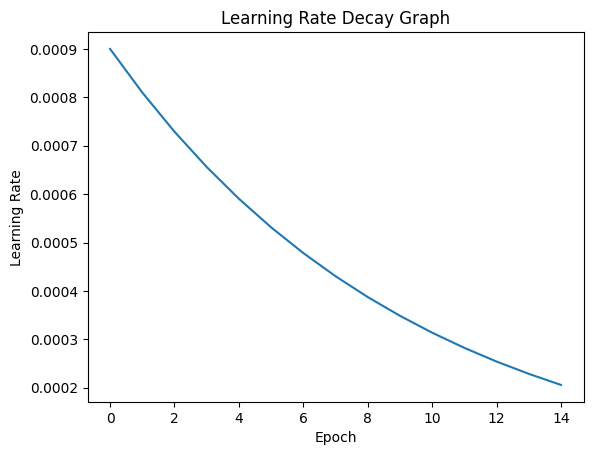

<function matplotlib.pyplot.xlabel(xlabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['left', 'center', 'right'] | None" = None, **kwargs) -> 'Text'>

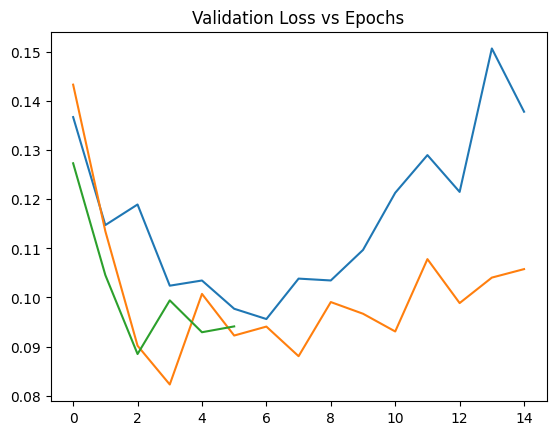

In [ ]:
# Import required libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping

# Load dataset (MNIST - simple handwritten digits dataset)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0


# Function to create model
def create_model(lr):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    optimizer = Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# 1. Train with fixed learning rate

fixed_lr = 0.001
model_fixed = create_model(fixed_lr)

history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

# 2. Learning Rate Decay Function
lr_list = []

def lr_decay(epoch, lr):
    new_lr = lr * 0.9   # reduce 10% every epoch
    lr_list.append(new_lr)
    return new_lr


lr_scheduler = LearningRateScheduler(lr_decay)

model_decay = create_model(0.001)

history_decay = model_decay.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=1
)

# 3. Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

model_early = create_model(0.001)

history_early = model_early.fit(
    x_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plt.figure()
plt.plot(lr_list)
plt.title("Learning Rate Decay Graph")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.show()

# 5. Epoch Comparison Graph
plt.figure()

plt.plot(history_fixed.history['val_loss'], label="Fixed LR")
plt.plot(history_decay.history['val_loss'], label="LR Decay")
plt.plot(history_early.history['val_loss'], label="Early Stopping")

plt.title("Validation Loss vs Epochs")
plt.xlabel